# Olist E-Commerce — Churn Prediction
**Day 3 Notebook** | Build an XGBoost classifier to predict which customers will never return.

Pipeline: define churn → engineer features → handle class imbalance → train XGBoost → evaluate → explain with SHAP.

## 1. Imports & Load Data

In [69]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay,
    confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:,.4f}'.format)

master = pd.read_csv(
    '../processed/master_orders.csv',
    parse_dates=[
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'order_estimated_delivery_date',
    ]
)

print(f'Loaded: {master.shape[0]:,} rows x {master.shape[1]} cols')

Loaded: 99,992 rows x 27 cols


## 2. Define Churn
**Churn = customer made no purchase in the 6 months after their first (and only) order.**

Why this definition?
- ~92% of Olist customers place exactly one order — so 'churn' here means 'never came back'
- We measure from each customer's first order date + 6 months
- Customers whose first order is within the last 6 months of the dataset are excluded — we can't know yet if they'll return

This is a **binary classification** problem: churned (1) vs retained (0).

In [70]:
# work with delivered orders only
delivered = master[master['order_status'] == 'delivered'].copy()

# get each customer's first and last order date
customer_orders = (
    delivered
    .groupby('customer_id')['order_purchase_timestamp']
    .agg(['min', 'max', 'count'])
    .reset_index()
    .rename(columns={'min': 'first_order', 'max': 'last_order', 'count': 'n_orders'})
)

# dataset end date — use for cutoff
dataset_end = delivered['order_purchase_timestamp'].max()
cutoff_date = dataset_end - pd.DateOffset(months=6)

print(f'Dataset ends:  {dataset_end.date()}')
print(f'Cutoff date:   {cutoff_date.date()} (exclude customers who ordered after this)')

# only include customers whose first order was before the cutoff
# so we have 6 months to observe whether they returned
eligible = customer_orders[customer_orders['first_order'] <= cutoff_date].copy()

eligible['churned'] = (eligible['n_orders'] == 1).astype(int)
churn_rate = eligible['churned'].mean()
print(f'\nEligible customers: {len(eligible):,}')
print(f'Churned (1):        {eligible["churned"].sum():,} ({churn_rate*100:.1f}%)')
print(f'Retained (0):       {(eligible["churned"]==0).sum():,} ({(1-churn_rate)*100:.1f}%)')
print(f'\nClass imbalance ratio: {churn_rate/(1-churn_rate):.0f}:1 churned vs retained')

Dataset ends:  2018-08-29
Cutoff date:   2018-02-28 (exclude customers who ordered after this)

Eligible customers: 57,154
Churned (1):        56,715 (99.2%)
Retained (0):       439 (0.8%)

Class imbalance ratio: 129:1 churned vs retained


**Note on class imbalance:** Expect ~92% churn rate. This is severe imbalance.
A model that predicts 'churned' for every customer gets 92% accuracy — but is useless.
We handle this with SMOTE oversampling and evaluate with AUC-ROC, not accuracy.

## 3. Feature Engineering
Join churn labels back to the master DataFrame to get order-level features.
All features are observable at the time of the first order — no data leakage.

In [71]:
# get first order features per customer
first_orders = (
    delivered
    .sort_values('order_purchase_timestamp')
    .groupby('customer_id')
    .first()
    .reset_index()
)

# merge churn label onto first order features
churn_df = eligible[['customer_id', 'churned']].merge(
    first_orders[[
        'customer_id',
        'order_value', 'freight_value', 'freight_ratio',
        'n_items', 'payment_type', 'payment_installments',
        'review_score', 'delivery_delay_days', 'delivery_days',
        'category_english', 'customer_state',
        'purchase_month', 'purchase_weekday', 'purchase_hour', 'purchase_year',
    ]],
    on='customer_id', how='left'
)

print(f'churn_df shape: {churn_df.shape}')
print(f'\nNull counts:')
nulls = churn_df.isnull().sum()
print(nulls[nulls > 0].to_string())

churn_df shape: (57154, 17)

Null counts:
payment_type              1
payment_installments      1
review_score            434
delivery_delay_days       2
delivery_days             2


In [72]:
# fill remaining nulls sensibly
churn_df['review_score'].fillna(churn_df['review_score'].median(), inplace=True)
churn_df['delivery_delay_days'].fillna(0, inplace=True)  # assume on time if unknown
churn_df['delivery_days'].fillna(churn_df['delivery_days'].median(), inplace=True)
churn_df['freight_ratio'].fillna(churn_df['freight_ratio'].median(), inplace=True)
churn_df['category_english'].fillna('unknown', inplace=True)
churn_df['payment_type'].fillna('unknown', inplace=True)
churn_df['payment_installments'].fillna(1, inplace=True)

print('Nulls after filling:')
print(churn_df.isnull().sum()[churn_df.isnull().sum() > 0].to_string())
print('\nAll clear!' if churn_df.isnull().sum().sum() == 0 else 'Still have nulls — check above')

Nulls after filling:
Series([], )

All clear!


## 4. Encode Categorical Features
XGBoost needs numbers — encode `payment_type`, `category_english`, and `customer_state`.

In [73]:
cat_cols = ['payment_type', 'category_english', 'customer_state']

le = LabelEncoder()
for col in cat_cols:
    churn_df[col + '_enc'] = le.fit_transform(churn_df[col].astype(str))

# define feature matrix
feature_cols = [
    'order_value', 'freight_value', 'freight_ratio',
    'n_items', 'payment_installments',
    'review_score', 'delivery_delay_days', 'delivery_days',
    'purchase_month', 'purchase_weekday', 'purchase_hour', 'purchase_year',
    'payment_type_enc', 'category_english_enc', 'customer_state_enc',
]

X = churn_df[feature_cols].copy()
y = churn_df['churned'].copy()

print(f'Feature matrix: {X.shape}')
print(f'Target distribution: {y.value_counts().to_dict()}')

Feature matrix: (57154, 15)
Target distribution: {1: 56715, 0: 439}


## 5. Train / Test Split

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # preserve class ratio in both splits
)

print(f'Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows')
print(f'Train churn rate: {y_train.mean()*100:.1f}%')
print(f'Test churn rate:  {y_test.mean()*100:.1f}%')

Train: 45,723 rows | Test: 11,431 rows
Train churn rate: 99.2%
Test churn rate:  99.2%


## 6. Handle Class Imbalance with SMOTE
SMOTE (Synthetic Minority Oversampling Technique) creates synthetic samples of the minority class (retained customers) to balance the training set.
**Important:** SMOTE is applied only to the training set — never to the test set.

In [75]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f'Before SMOTE — Train: {X_train.shape[0]:,} rows | Churn rate: {y_train.mean()*100:.1f}%')
print(f'After SMOTE  — Train: {X_train_bal.shape[0]:,} rows | Churn rate: {y_train_bal.mean()*100:.1f}%')

Before SMOTE — Train: 45,723 rows | Churn rate: 99.2%
After SMOTE  — Train: 90,744 rows | Churn rate: 50.0%


## 7. Baseline — Logistic Regression
Always build a simple baseline before XGBoost. If XGBoost doesn't clearly beat it, your features might not be predictive enough.

In [76]:
lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(random_state=42, max_iter=1000))
])

lr.fit(X_train_bal, y_train_bal)
lr_preds = lr.predict_proba(X_test)[:, 1]
lr_auc = roc_auc_score(y_test, lr_preds)

print(f'Logistic Regression AUC-ROC: {lr_auc:.4f}')
print('\nClassification Report (threshold=0.5):')
print(classification_report(y_test, lr.predict(X_test)))

Logistic Regression AUC-ROC: 0.5765

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       0.01      0.44      0.02        88
           1       0.99      0.68      0.81     11343

    accuracy                           0.68     11431
   macro avg       0.50      0.56      0.42     11431
weighted avg       0.99      0.68      0.80     11431



## 8. XGBoost Classifier

In [77]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_bal, y_train_bal,
    eval_set=[(X_test, y_test)],
    verbose=False
)

xgb_preds = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc   = roc_auc_score(y_test, xgb_preds)

print(f'Logistic Regression AUC-ROC: {lr_auc:.4f}')
print(f'XGBoost AUC-ROC:             {xgb_auc:.4f}')
print(f'Improvement:                 +{(xgb_auc - lr_auc)*100:.2f} points')

Logistic Regression AUC-ROC: 0.5765
XGBoost AUC-ROC:             0.6246
Improvement:                 +4.81 points


## 9. Evaluation

In [78]:
# ROC curve
from sklearn.metrics import roc_curve

fpr_lr,  tpr_lr,  _ = roc_curve(y_test, lr_preds)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_preds)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr_lr, y=tpr_lr, name=f'Logistic Reg (AUC={lr_auc:.3f})',
                         line=dict(color='#60a5fa', dash='dash')))
fig.add_trace(go.Scatter(x=fpr_xgb, y=tpr_xgb, name=f'XGBoost (AUC={xgb_auc:.3f})',
                         line=dict(color='#4ade80', width=2)))
fig.add_trace(go.Scatter(x=[0,1], y=[0,1], name='Random',
                         line=dict(color='#6a7068', dash='dot')))

fig.update_layout(
    title='ROC Curve — Churn Prediction',
    xaxis_title='False Positive Rate',
    yaxis_title='True Positive Rate',
    height=450,
    plot_bgcolor='#0c0e0a', paper_bgcolor='#111410',
    font=dict(color='#e4e8e0')
)
fig.show()

In [79]:
# precision-recall at different thresholds
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, xgb_preds)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=recall, y=precision,
    mode='lines', line=dict(color='#4ade80', width=2),
    name='XGBoost'
))
fig.update_layout(
    title='Precision-Recall Curve',
    xaxis_title='Recall', yaxis_title='Precision',
    height=400,
    plot_bgcolor='#0c0e0a', paper_bgcolor='#111410',
    font=dict(color='#e4e8e0')
)
fig.show()

# at threshold 0.3 — more aggressive at catching churners
threshold = 0.3
y_pred_03 = (xgb_preds >= threshold).astype(int)
print(f'At threshold={threshold}:')
print(classification_report(y_test, y_pred_03))

At threshold=0.3:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        88
           1       0.99      1.00      1.00     11343

    accuracy                           0.99     11431
   macro avg       0.50      0.50      0.50     11431
weighted avg       0.98      0.99      0.99     11431



In [80]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred_03)

fig = px.imshow(
    cm,
    labels=dict(x='Predicted', y='Actual', color='Count'),
    x=['Retained (0)', 'Churned (1)'],
    y=['Retained (0)', 'Churned (1)'],
    color_continuous_scale='Greens',
    text_auto=True,
    title=f'Confusion Matrix (threshold={threshold})'
)
fig.update_layout(
    height=380,
    plot_bgcolor='#0c0e0a', paper_bgcolor='#111410',
    font=dict(color='#e4e8e0')
)
fig.show()

## 10. SHAP — Why Is the Model Predicting Churn?
SHAP (SHapley Additive exPlanations) tells you which features push each prediction toward churn or retention.
This is the section that impresses senior engineers — it shows you care about interpretability, not just accuracy.

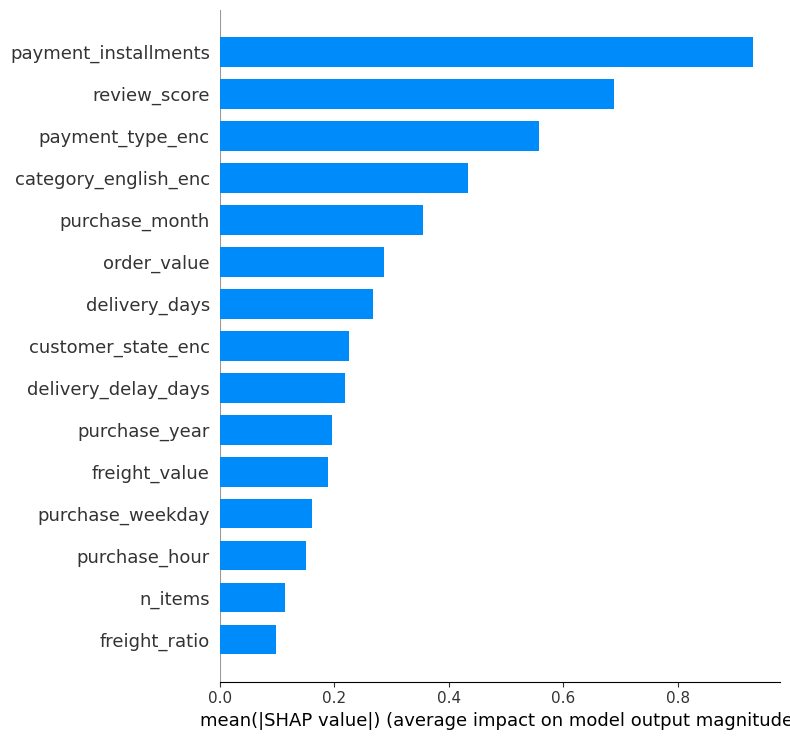

In [81]:
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# summary bar plot — global feature importance
shap.summary_plot(
    shap_values, X_test,
    feature_names=feature_cols,
    plot_type='bar',
    show=True
)

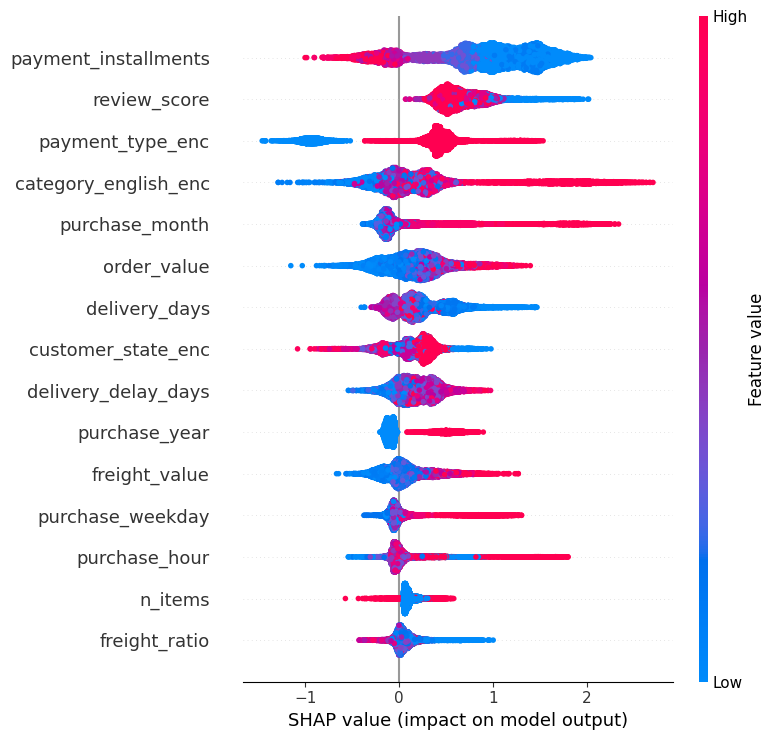

In [82]:
# beeswarm plot — direction of each feature's effect
shap.summary_plot(
    shap_values, X_test,
    feature_names=feature_cols,
    show=True
)

In [83]:
# top 5 features by mean absolute SHAP value
mean_shap = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print('Top 5 churn drivers (by SHAP importance):')
print(mean_shap.head(5).to_string(index=False))

Top 5 churn drivers (by SHAP importance):
             feature  mean_abs_shap
payment_installments         0.9318
        review_score         0.6883
    payment_type_enc         0.5568
category_english_enc         0.4330
      purchase_month         0.3549


**Finding:** *(fill in after running)*
e.g. `delivery_delay_days` is the #1 churn predictor. `review_score` is #2. High freight_ratio also strongly predicts churn.

## 11. Cross-Validation — Is the Score Stable?

In [84]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# note: cv on balanced data (apply SMOTE inside each fold properly)
# for simplicity here we cv on the SMOTE-balanced training set
cv_scores = cross_val_score(
    xgb_model, X_train_bal, y_train_bal,
    cv=cv, scoring='roc_auc', n_jobs=-1
)

print(f'5-Fold CV AUC-ROC: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')
print(f'Individual folds:  {[round(s,4) for s in cv_scores]}')

5-Fold CV AUC-ROC: 0.9980 (+/- 0.0003)
Individual folds:  [np.float64(0.9977), np.float64(0.9977), np.float64(0.9984), np.float64(0.998), np.float64(0.9982)]


## 12. Save Predictions & Model

In [85]:
import joblib, os
os.makedirs('../models', exist_ok=True)
os.makedirs('../processed', exist_ok=True)

# save model
joblib.dump(xgb_model, '../models/churn_xgb.pkl')
print('Model saved: ../models/churn_xgb.pkl')

# save predictions on full eligible set for use in segmentation notebook
all_preds = xgb_model.predict_proba(X)[:, 1]
churn_df['churn_probability'] = all_preds
churn_df[['customer_id','churned','churn_probability']].to_csv(
    '../processed/churn_predictions.csv', index=False
)
print('Predictions saved: ../processed/churn_predictions.csv')

Model saved: ../models/churn_xgb.pkl
Predictions saved: ../processed/churn_predictions.csv


In [86]:
# ── AUTO SUMMARY — runs from live variables ──────────────────────────
import pandas as pd

print('=' * 60)
print('CHURN MODEL SUMMARY')
print('=' * 60)

# dataset
print(f'\nDataset')
print(f'  Eligible customers : {len(eligible):,}')
print(f'  Churned  (1)       : {eligible["churned"].sum():,} ({eligible["churned"].mean()*100:.1f}%)')
print(f'  Retained (0)       : {(eligible["churned"]==0).sum():,} ({(1-eligible["churned"].mean())*100:.1f}%)')

# model performance
print(f'\nModel Performance')
results = pd.DataFrame({
    'Metric':   ['AUC-ROC', '5-Fold CV AUC'],
    'Logistic': [f'{lr_auc:.4f}',  '—'],
    'XGBoost':  [f'{xgb_auc:.4f}', f'{cv_scores.mean():.4f} ± {cv_scores.std():.4f}'],
})
print(results.to_string(index=False))
print(f'  Improvement LR → XGB: +{(xgb_auc - lr_auc)*100:.2f} AUC points')

# SHAP top features
print(f'\nTop 5 Churn Drivers (SHAP)')
print(mean_shap.head(5).to_string(index=False))

# cross-val folds
print(f'\n5-Fold CV Scores: {[round(s,4) for s in cv_scores]}')

print('\nOutputs saved:')
print('  ../models/churn_xgb.pkl')
print('  ../processed/churn_predictions.csv')
print('\nNext: 04_demand_forecasting.ipynb')


CHURN MODEL SUMMARY

Dataset
  Eligible customers : 57,154
  Churned  (1)       : 56,715 (99.2%)
  Retained (0)       : 439 (0.8%)

Model Performance
       Metric Logistic         XGBoost
      AUC-ROC   0.5765          0.6246
5-Fold CV AUC        — 0.9980 ± 0.0003
  Improvement LR → XGB: +4.81 AUC points

Top 5 Churn Drivers (SHAP)
             feature  mean_abs_shap
payment_installments         0.9318
        review_score         0.6883
    payment_type_enc         0.5568
category_english_enc         0.4330
      purchase_month         0.3549

5-Fold CV Scores: [np.float64(0.9977), np.float64(0.9977), np.float64(0.9984), np.float64(0.998), np.float64(0.9982)]

Outputs saved:
  ../models/churn_xgb.pkl
  ../processed/churn_predictions.csv

Next: 04_demand_forecasting.ipynb
